In [2]:
import sys
import pathlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import seaborn as sns


# Seismic Metadata – EDA Dashboard

Charts
------
1. Pie  – earthquake_local traces per Station Code   (top 10 + Other)
2. Pie  – All traces per Station Network Code         (top 10 + Other)
3. Pie  – All traces per Trace Channel
4. Hexbin – Magnitude vs Source Distance              (earthquake_local)
5. Histogram – Trace Start Time distribution
6. Histogram + KDE – Source Magnitude distribution
7. Dual-axis Histogram – Source Depth + Depth Uncertainty

# Configuration and theme

In [3]:

warnings.filterwarnings("ignore", category=FutureWarning)

CSV_PATH   = pathlib.Path(r"D:\Desktop\Intership IT\SismicDataAnalysis\.seisbench\STEAD\metadata.csv")
OUT_PATH   = pathlib.Path("./EDAPlots")
TOP_N      = 10          # how many slices to name before collapsing to "Other"
DEPTH_MAX  = 80          # km  – clip for readability
DEPTH_U_MAX = 10         # km  – clip uncertainty axis

DARK_BG  = "#FDFFF7"
CARD_BG  = "#1a1d27"
TEXT_COL = "#1a1d27"
MUTED    = "#64748b"
VIOLET   = "#7c6af7"
AMBER    = "#f59e0b"

sns.set_theme(style="whitegrid", font_scale=1.0)

# Helpers

In [5]:
def make_pie_data(series: pd.Series, top_n: int = TOP_N) -> pd.Series:
    """Return top-N value counts + an aggregated 'Other' slice."""
    counts = series.value_counts()
    top    = counts.iloc[:top_n]
    other  = counts.iloc[top_n:].sum()
    if other > 0:
        return pd.concat([top, pd.Series({"Other": other})])
    return top


def draw_donut(ax, pie_data: pd.Series, palette, title: str,
               centre_label: str = "") -> None:
    """Draw a donut chart on *ax* with a legend and optional centre label."""
    wedges, _, autotexts = ax.pie(
        pie_data.values,
        labels=None,
        autopct=lambda p: f"{p:.1f}%" if p > 2 else "",
        pctdistance=0.78,
        colors=palette,
        startangle=140,
        wedgeprops=dict(linewidth=1.4, edgecolor=DARK_BG),
        textprops=dict(color=TEXT_COL, fontsize=8),
    )
    for at in autotexts:
        at.set_fontsize(7.5)
        at.set_color(DARK_BG)
        at.set_fontweight("bold")

    ax.legend(
        wedges, pie_data.index,
        title_fontsize=8,
        loc="lower left",
        bbox_to_anchor=(-0.32, 0.0),
        fontsize=8,
        labelcolor=TEXT_COL,
        framealpha=0,
    )
    ax.set_title(title, color=TEXT_COL, fontsize=11, pad=12)

    # Donut hole
    hole = plt.Circle((0, 0), 0.42, fc=DARK_BG)
    ax.add_patch(hole)
    if centre_label:
        ax.text(0, 0, centre_label, ha="center", va="center",
                fontsize=9, color=TEXT_COL, fontweight="bold")
    ax.set_facecolor(CARD_BG)


def style_axis(ax) -> None:
    """Apply common dark-theme styling to a rectangular axis."""
    ax.set_facecolor(CARD_BG)
    ax.tick_params(colors=TEXT_COL)
    for sp in ax.spines.values():
        sp.set_edgecolor(MUTED)
    ax.grid(axis="y", color=MUTED, linestyle="--", linewidth=0.4, alpha=0.4)

In [7]:
df = pd.read_csv(CSV_PATH, low_memory=False)
df["trace_start_time"] = pd.to_datetime(df["trace_start_time"], errors="coerce")

eq = df[df["trace_category"] == "earthquake_local"].copy()
print(f"  Total rows : {len(df):,}")
print(f"  earthquake_local rows: {len(eq):,}")

  Total rows : 1,265,657
  earthquake_local rows: 1,030,231


In [8]:
no = df[df["trace_category"] == "noise"].copy()
print(f"  noise rows: {len(no):,}")

  noise rows: 235,426


# Pie chart: earthquake and noise per Station Code

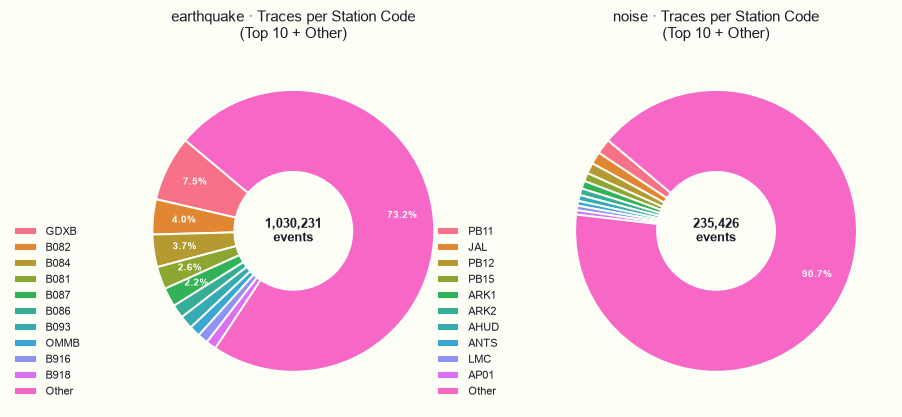

In [48]:
fig = plt.figure(figsize=(10, 10), facecolor=DARK_BG)
gs = gridspec.GridSpec(
    1, 2, figure=fig,
)

ax1 = fig.add_subplot(gs[0, 0])
d_stat = make_pie_data(eq["station_code"])
draw_donut(
    ax1, d_stat,
    palette=sns.color_palette("husl", len(d_stat)),
    title="earthquake · Traces per Station Code\n(Top 10 + Other)",
    centre_label=f"{len(eq):,}\nevents",
)

ax1 = fig.add_subplot(gs[0, 1])
d_stat = make_pie_data(no["station_code"])
draw_donut(
    ax1, d_stat,
    palette=sns.color_palette("husl", len(d_stat)),
    title="noise · Traces per Station Code\n(Top 10 + Other)",
    centre_label=f"{len(no):,}\nevents",
)

# Pie chart: all traces / Noise / earthquake per Station Network Code


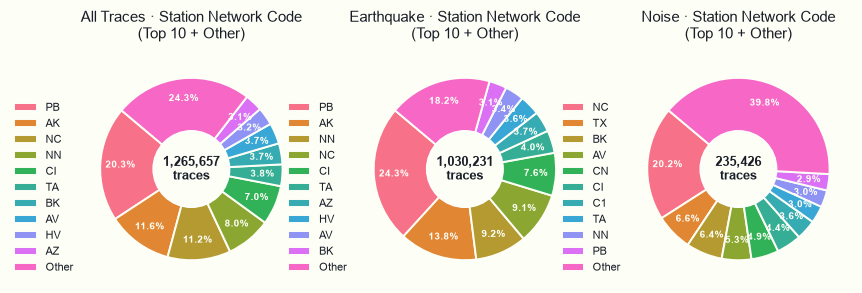

In [50]:
fig = plt.figure(figsize=(10, 20), facecolor=DARK_BG)
gs = gridspec.GridSpec(
    1, 3, figure=fig
)

ax2 = fig.add_subplot(gs[0, 0])
d_net = make_pie_data(df["station_network_code"])
draw_donut(
    ax2, d_net,
    palette=sns.color_palette("husl", len(d_net)),
    title="All Traces · Station Network Code\n(Top 10 + Other)",
    centre_label=f"{len(df):,}\ntraces",
)
ax2 = fig.add_subplot(gs[0, 1])
d_net = make_pie_data(eq["station_network_code"])
draw_donut(
    ax2, d_net,
    palette=sns.color_palette("husl", len(d_net)),
    title="Earthquake · Station Network Code\n(Top 10 + Other)",
    centre_label=f"{len(eq):,}\ntraces",
)
ax2 = fig.add_subplot(gs[0, 2])
d_net = make_pie_data(no["station_network_code"])
draw_donut(
    ax2, d_net,
    palette=sns.color_palette("husl", len(d_net)),
    title="Noise · Station Network Code\n(Top 10 + Other)",
    centre_label=f"{len(no):,}\ntraces",
)

Pie chart: Trace Channel

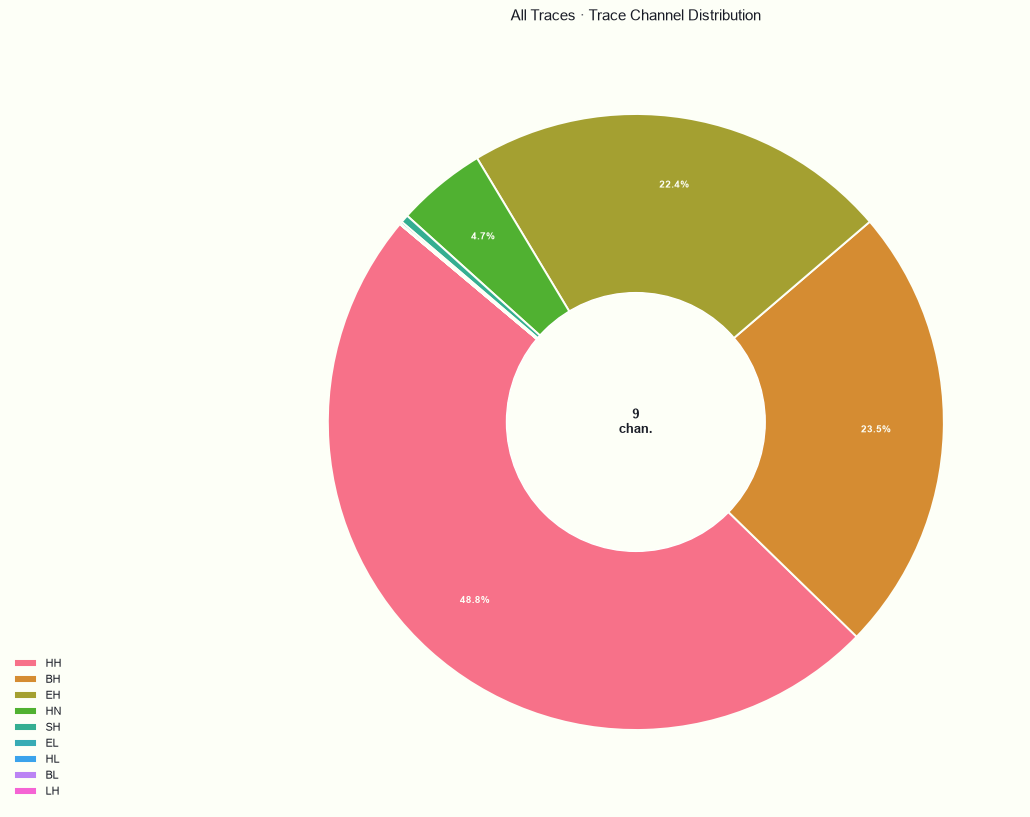

In [51]:
fig = plt.figure(figsize=(10, 10), facecolor=DARK_BG)
gs = gridspec.GridSpec(
    1, 1, figure=fig
)
ax3 = fig.add_subplot(gs[0, 0])
d_chan = make_pie_data(df["trace_channel"])
draw_donut(
    ax3, d_chan,
    palette=sns.color_palette("husl", len(d_chan)),
    title="All Traces · Trace Channel Distribution",
    centre_label=f"{df['trace_channel'].nunique()}\nchan.",
)

# Histogram + KDE: Source Magnitude

Text(0.5, 1.0, 'Source Magnitude Distribution')

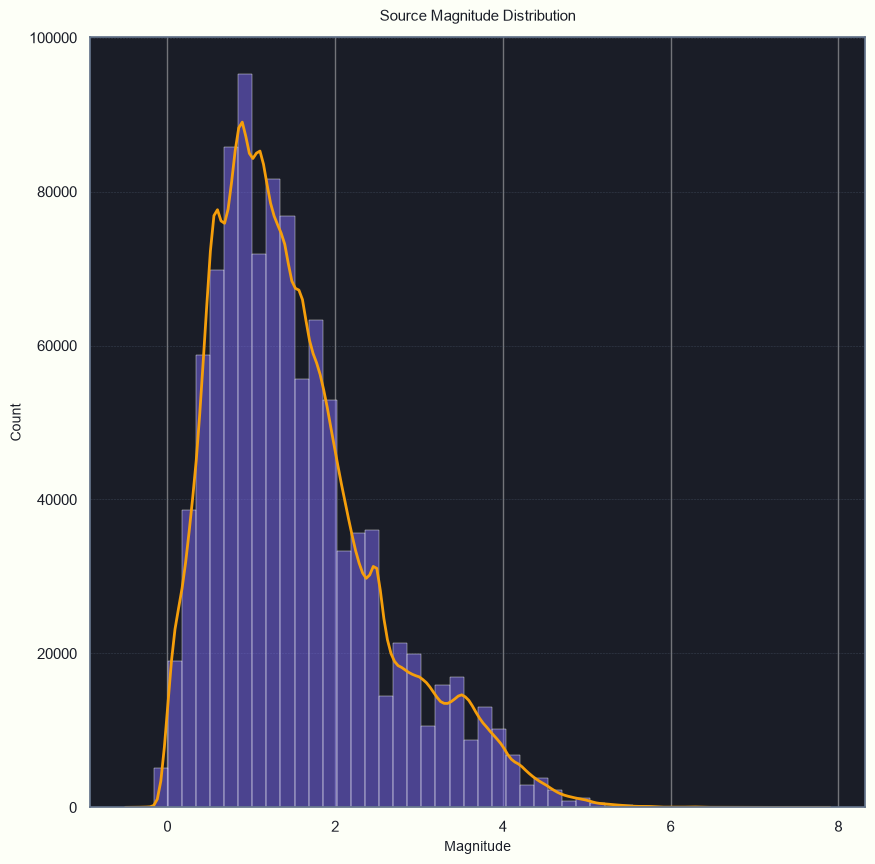

In [10]:
fig = plt.figure(figsize=(10, 10), facecolor=DARK_BG)
gs = gridspec.GridSpec(
    1, 1, figure=fig
)
ax6 = fig.add_subplot(gs[0, 0])
style_axis(ax6)

mag = df["source_magnitude"].dropna()
sns.histplot(
    mag, bins=50, kde=True, color=VIOLET, ax=ax6,
    line_kws=dict(color=AMBER, linewidth=2),
    edgecolor=DARK_BG, linewidth=0.3,
)
# Force KDE line colour (seaborn may override)
for line in ax6.lines:
    line.set_color(AMBER)

ax6.set_xlabel("Magnitude", color=TEXT_COL, fontsize=10)
ax6.set_ylabel("Count",     color=TEXT_COL, fontsize=10)
ax6.set_title("Source Magnitude Distribution", color=TEXT_COL, fontsize=11, pad=12)

# Distribution plot, source distance


Text(0.5, 1.0, 'Source Distance Distribution')

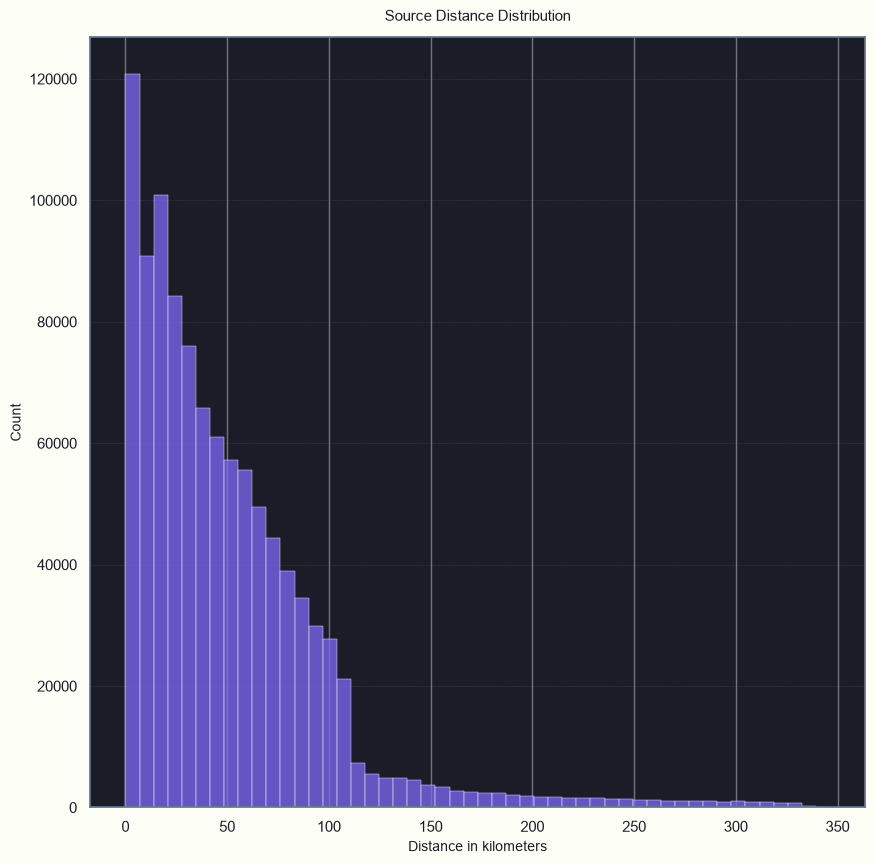

In [15]:
fig = plt.figure(figsize=(10, 10), facecolor=DARK_BG)
gs = gridspec.GridSpec(
    1, 1, figure=fig
)
ax6 = fig.add_subplot(gs[0, 0])
style_axis(ax6)

dist = df["source_distance_km"].dropna()
sns.histplot(
    dist, bins=50, color=VIOLET, ax=ax6,
    edgecolor=DARK_BG, linewidth=0.3,
)

ax6.set_xlabel("Distance in kilometers", color=TEXT_COL, fontsize=10)
ax6.set_ylabel("Count",     color=TEXT_COL, fontsize=10)
ax6.set_title("Source Distance Distribution", color=TEXT_COL, fontsize=11, pad=12)



# Hexbin plot : Magnitude vs Source Distance  (earthquake_local)

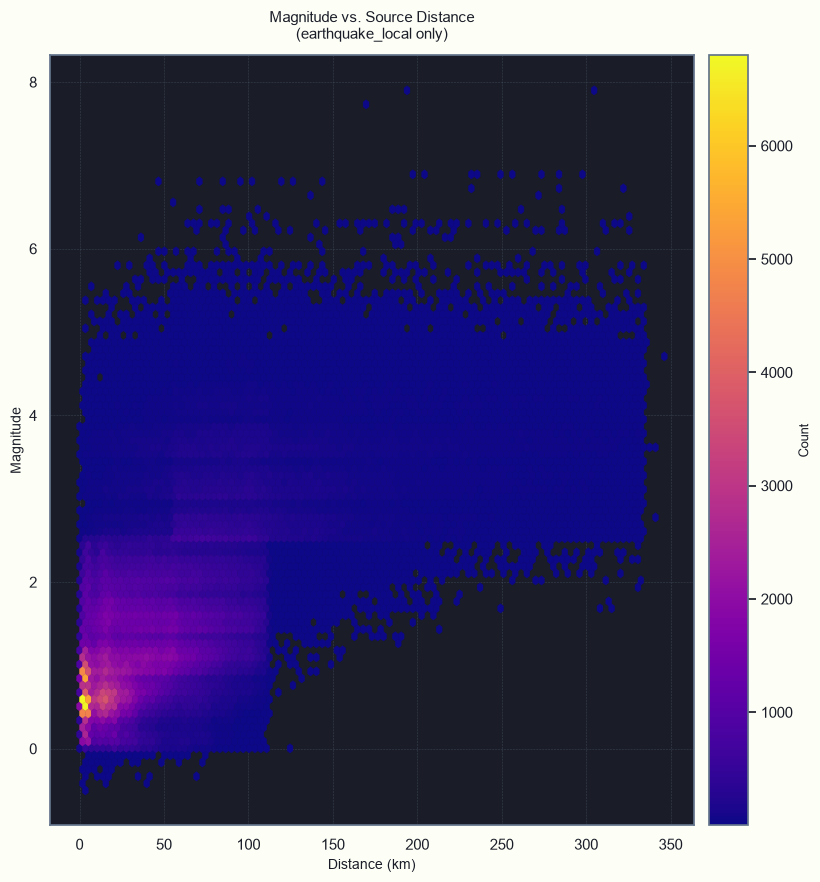

In [56]:
fig = plt.figure(figsize=(10, 10), facecolor=DARK_BG)
gs = gridspec.GridSpec(
    1, 1, figure=fig
)

ax4 = fig.add_subplot(gs[0, 0])
style_axis(ax4)

hb_data = eq[["source_magnitude", "source_distance_km"]].dropna()
hb = ax4.hexbin(
    hb_data["source_distance_km"],
    hb_data["source_magnitude"],
    gridsize=(100,50),
    cmap="plasma",
    mincnt=1,
    linewidths=0.3,
)
cb = fig.colorbar(hb, ax=ax4, pad=0.02)
cb.set_label("Count", color=TEXT_COL, fontsize=9)
cb.ax.yaxis.set_tick_params(color=TEXT_COL)
plt.setp(cb.ax.yaxis.get_ticklabels(), color=TEXT_COL)
cb.outline.set_edgecolor(MUTED)

ax4.set_xlabel("Distance (km)", color=TEXT_COL, fontsize=10)
ax4.set_ylabel("Magnitude",     color=TEXT_COL, fontsize=10)
ax4.set_title(
    "Magnitude vs. Source Distance\n(earthquake_local only)",
    color=TEXT_COL, fontsize=11, pad=12,
)
ax4.grid(color=MUTED, linestyle="--", linewidth=0.4, alpha=0.4)

Histogram: Trace Start Time

Text(0.5, 1.0, 'Trace Start Time Distribution')

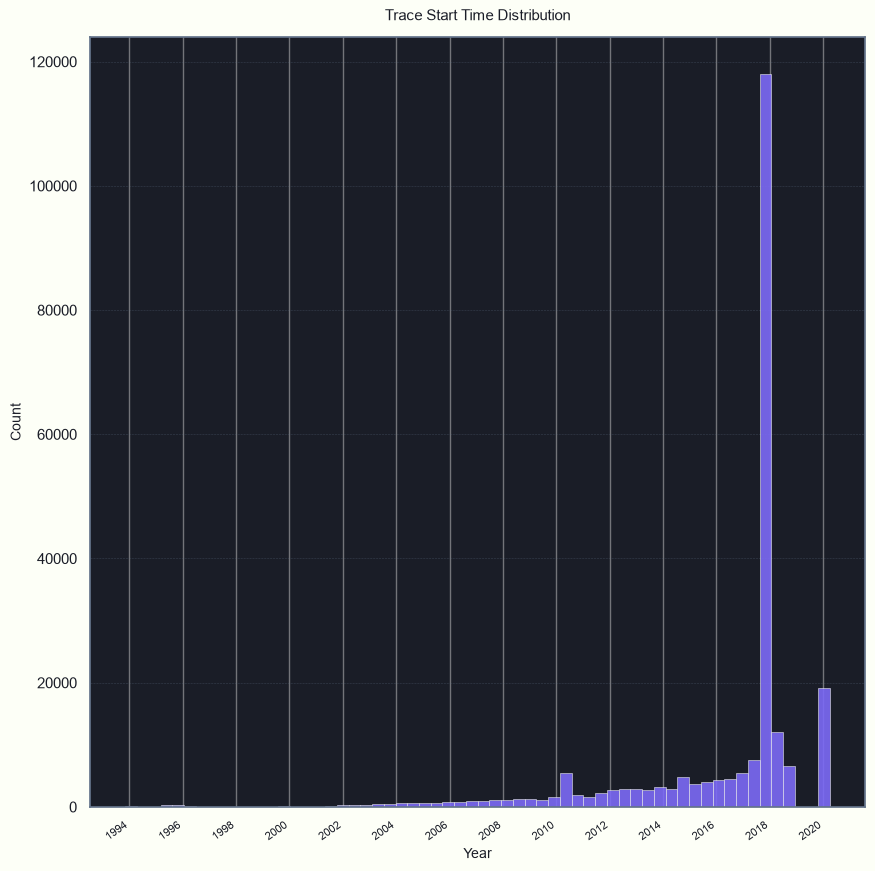

In [57]:
fig = plt.figure(figsize=(10, 10), facecolor=DARK_BG)
gs = gridspec.GridSpec(
    1, 1, figure=fig
)

ax5 = fig.add_subplot(gs[0, 0])
style_axis(ax5)

ts = df["trace_start_time"].dropna()
ax5.hist(ts, bins=60, color=VIOLET, edgecolor=DARK_BG, linewidth=0.4, alpha=0.9)
ax5.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax5.xaxis.set_major_locator(mdates.YearLocator(2))
plt.setp(ax5.get_xticklabels(), rotation=35, ha="right", color=TEXT_COL, fontsize=8)
ax5.set_xlabel("Year",  color=TEXT_COL, fontsize=10)
ax5.set_ylabel("Count", color=TEXT_COL, fontsize=10)
ax5.set_title("Trace Start Time Distribution", color=TEXT_COL, fontsize=11, pad=12)



 Dual-axis Histogram: Depth + Depth Uncertainty  (full width)

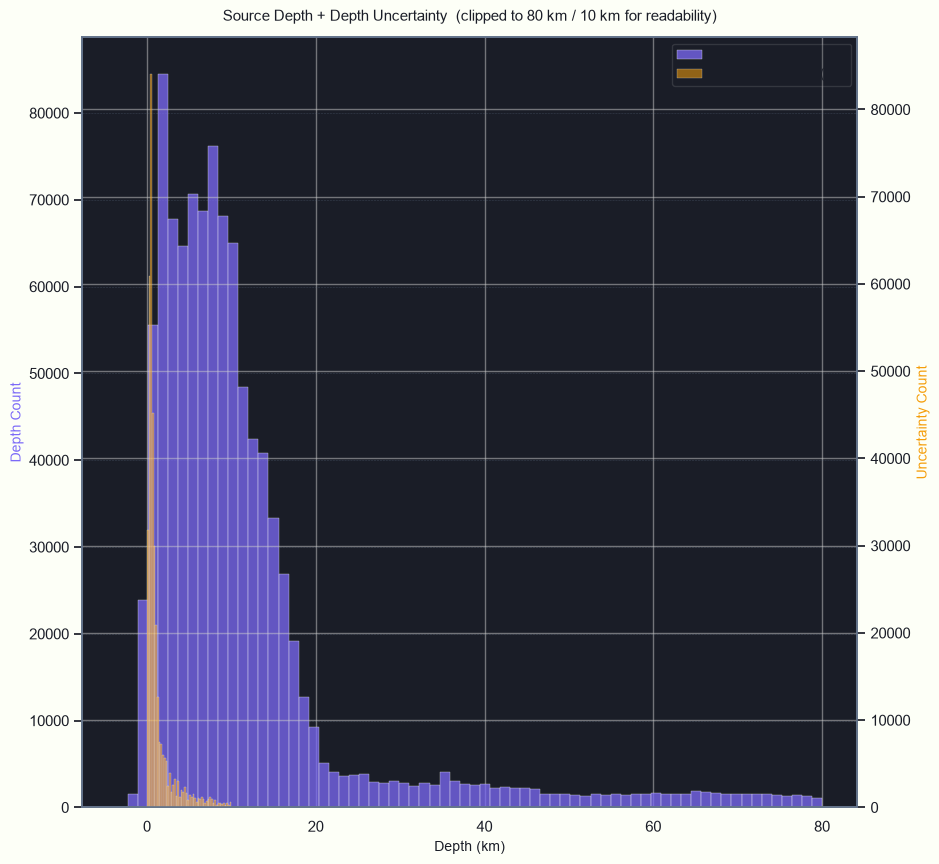

In [59]:
fig = plt.figure(figsize=(10, 10), facecolor=DARK_BG)
gs = gridspec.GridSpec(
    1, 1, figure=fig
)
ax7 = fig.add_subplot(gs[0, :])
style_axis(ax7)

depth    = df["source_depth_km"].dropna()
depth_uc = df["source_depth_uncertainty_km"].dropna()
depth_c    = depth[depth    <= DEPTH_MAX]
depth_uc_c = depth_uc[depth_uc <= DEPTH_U_MAX]

ax7.hist(
    depth_c, bins=70,
    color=VIOLET, alpha=0.75,
    edgecolor=DARK_BG, linewidth=0.3,
    label="Source Depth (km)",
)

ax7r = ax7.twinx()
ax7r.hist(
    depth_uc_c, bins=50,
    color=AMBER, alpha=0.55,
    edgecolor=DARK_BG, linewidth=0.3,
    label="Depth Uncertainty (km)",
)
ax7r.set_ylabel("Uncertainty Count", color=AMBER, fontsize=10)
ax7r.yaxis.label.set_color(AMBER)
ax7r.tick_params(colors=TEXT_COL)
for sp in ax7r.spines.values():
    sp.set_edgecolor(MUTED)

ax7.set_xlabel("Depth (km)", color=TEXT_COL, fontsize=10)
ax7.set_ylabel("Depth Count", color=VIOLET, fontsize=10)
ax7.set_title(
    f"Source Depth + Depth Uncertainty  "
    f"(clipped to {DEPTH_MAX} km / {DEPTH_U_MAX} km for readability)",
    color=TEXT_COL, fontsize=11, pad=12,
)

# Combined legend
h1, l1 = ax7.get_legend_handles_labels()
h2, l2 = ax7r.get_legend_handles_labels()
ax7.legend(
    h1 + h2, l1 + l2,
    loc="upper right", fontsize=9,
    labelcolor=TEXT_COL, framealpha=0.15, facecolor=CARD_BG,
)



In [ ]:
plt.savefig(OUT_PATH, dpi=160, bbox_inches="tight", facecolor=DARK_BG)
print(f"Saved → {OUT_PATH}")